## This code identifies candidate based on the given cluster dictionaries and the generated bipartite network

## Updates:
In this line of code, we will show consideration for converting between Pd/Ni based reactions by the percent difference in similarity for each class of ligands from computational calculations, and from experimental overlap


Hypothesis: If there are more overlap for Pd and Ni found in literature for that reaction, it would increase the likelihood for Pd/Ni conversion



In [1]:
import pandas as pd
import networkx as nx
import itertools
import matplotlib.pyplot as plt
import random
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score, auc
import json
from networkx.algorithms import bipartite

In [2]:
# Get cluster information by reading the JSON string from the .txt file
with open('cluster_dictionaries.txt', 'r') as file:
    json_data = file.read()

# Convert the JSON string back to a dictionary
cluster_dictionaries = json.loads(json_data)

# Extract individual dictionaries
cluster_dict_all_descriptor = cluster_dictionaries['cluster_dict_all_descriptor']
cluster_dict_nbo_descriptor = cluster_dictionaries['cluster_dict_nbo_descriptor']
cluster_dict_vbur_descriptor = cluster_dictionaries['cluster_dict_vbur_descriptor']

# Print the dictionaries to verify
print("cluster_dict_all_descriptor:", cluster_dict_all_descriptor)
print("cluster_dict_nbo_descriptor:", cluster_dict_nbo_descriptor)
print("cluster_dict_vbur_descriptor:", cluster_dict_vbur_descriptor)

# Get the number of items for each dictionary
count_all_descriptor = len(cluster_dict_all_descriptor)
count_nbo_descriptor = len(cluster_dict_nbo_descriptor)
count_vbur_descriptor = len(cluster_dict_vbur_descriptor)

# Print the counts
print(f"Number of items in 'cluster_dict_all_descriptor': {count_all_descriptor}")
print(f"Number of items in 'cluster_dict_nbo_descriptor': {count_nbo_descriptor}")
print(f"Number of items in 'cluster_dict_vbur_descriptor': {count_vbur_descriptor}")


def count_items_in_dict(dictionary):
    """
    Count the number of items in each dictionary and the number of strings in the lists.

    Args:
        dictionary (dict): Dictionary where keys are cluster names and values are lists of strings.

    Prints:
        The key and the number of strings in each list.
    """
    for key, value in dictionary.items():
        list_length = len(value)  # Count the number of strings in the list
        print(f"Key: {key}, Number of strings: {list_length}")


# Count for each dictionary
print("For cluster_dict_all_descriptor:")
count_items_in_dict(cluster_dict_all_descriptor)

print("\nFor cluster_dict_nbo_descriptor:")
count_items_in_dict(cluster_dict_nbo_descriptor)

print("\nFor cluster_dict_vbur_descriptor:")
count_items_in_dict(cluster_dict_vbur_descriptor)

# Extract a list of ligand_ids that are from DFT calculations
dft_ligand_ids = []

# Iterate through the dictionary and collect all ligand_ids
for cluster, ligand_ids in cluster_dict_all_descriptor.items():
    dft_ligand_ids.extend(ligand_ids)

# Print the total number of ligand_ids
num_dft_ligand_ids = len(dft_ligand_ids)
print(num_dft_ligand_ids)


cluster_dict_all_descriptor: {'c1': ['346', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '163', '174', '176', '177', '178', '179', '180', '181', '338', '337', '336', '335', '175', '162', '161', '160', '241', '313', '314', '139', '140', '141', '142', '347', '145', '146', '147', '148', '149', '150', '151', '316', '345', '344', '343', '342', '317', '318', '319', '334', '333', '332', '331', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '325', '324', '323', '322', '321', '237', '238', '239', '240', '217', '357', '216', '214', '330', '328', '327', '326', '195', '196', '197', '198', '199', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '210', '211', '212', '213', '215', '358', '356', '359', '434', '429', '428', '427', '426', '425', '060', '071', '072', '435', '073', '075', '076', '077', '129', '424', '423', '422', '421', '420', '074', '436', '437', '450', '004', '005', '006', '007', '008', '009

In [3]:
# File name of the CSV document containing the ligand dataset
file_name = 'master_ligand_dataset_4.csv'

# Read the CSV file
df = pd.read_csv(file_name)
df = df.dropna(how='all')  # Remove rows where all values are NaN
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Remove columns with 'Unnamed'
df['lig_id'] = df['lig_id'].astype(int)  # Ensure 'lig_id' is of type int


In [4]:
df

,lig_id,ligand_name,SMILES,exp_id,ref,substrate_comb,metal,substrate_1,substrate_1_smiles,substrate_2,...,additive,additive_equiv,substrate_ratio,volume_ml,activity_kg_mol,yield,mn,time_hr,incorporatio_ratio,ton
0,1,n-n-1,CN(CCN(C)C)C,1,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,ch3i,10,NaN,4.0,NaN,21.0,NaN,3.0,NaN,NaN
1,1,n-n-1,CN(CCN(C)C)C,2,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,ch3i,100,NaN,4.0,NaN,56.0,NaN,3.0,NaN,NaN
2,2,p-p-1,P(CCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4=...,3,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,ch3i,10,NaN,4.0,NaN,14.0,NaN,48.0,NaN,NaN
3,2,p-p-1,P(CCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4=...,4,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,ch3i,100,NaN,4.0,NaN,29.0,NaN,48.0,NaN,NaN
4,3,p-p-2,P(CCCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4...,5,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,ch3i,10,NaN,4.0,NaN,18.0,NaN,24.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2138,480,p-p-35,dippf,2152,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,20.0,NaN,2.0,NaN,NaN
2139,476,p-p-31,dtbpf,2153,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,30.0,NaN,2.0,NaN,NaN
2140,2,p-p-1,P(CCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4=...,2154,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,71.0,NaN,2.0,NaN,NaN
2141,4,p-p-3,P(CCCCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C...,2155,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,75.0,NaN,2.0,NaN,NaN


In [5]:
# for each reaction node (substrate_1 substrate_2) combination, identify:
# 1. whether both ni/pd catalyzed reaction have been demonstrated (better conversion possibility)
# 2. whether the same ligand has been shown with Pd/Ni (stronger conversion possibility)

# Find out total no. of ligands used for that reaction. 
# find out how many ligands are w/ Ni, how many w/ Pd
# 

In [6]:
# Filter the DataFrame for rows where substrate_1 is 'CO2'
filtered_df = df[df['substrate_1'] == 'CO2']

# Get unique lig_id values
unique_lig_ids = filtered_df['lig_id'].unique()

# Convert to list (if needed)
unique_lig_ids_list = unique_lig_ids.tolist()

print(unique_lig_ids_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 71, 72, 14, 15, 16, 17, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 64, 65, 66, 67, 68, 69, 70, 44, 410, 474, 475, 486, 487]


In [7]:
columns_of_interest = ['ligand_name', 'lig_id', 'substrate_1', 'substrate_2']
lig_rxn_df = df[columns_of_interest]

# Convert 'lig_id' to string with leading zeros
lig_rxn_df['lig_id'] = lig_rxn_df['lig_id'].apply(lambda x: f"{x:03}")

# Identify rows to remove from lig_rxn_df
removed_ligand_ids = lig_rxn_df.loc[~lig_rxn_df['lig_id'].isin(dft_ligand_ids), 'lig_id'].tolist()
print("Experimental Ligand ids not calculated:", set(removed_ligand_ids))

# If lig_id from this experimental dataframe isn't in the dft_lig_id list, remove the row
lig_rxn_df = lig_rxn_df[lig_rxn_df['lig_id'].isin(dft_ligand_ids)]

unique_lig_ids_df = set(lig_rxn_df['lig_id'].unique())
print('Updated number for number of experimental ligand ids:', len(unique_lig_ids_df))

unique_dft_ligand_ids = set(dft_ligand_ids)
# assert len(unique_lig_ids_df) == len(unique_dft_ligand_ids), f"Mismatch in unique lig_id counts: ligand-id has {len(unique_lig_ids_df)}, DFT-ligand_list has {len(unique_dft_ligand_ids)}"

# Update the cluster dictionaries by keeping only those ligand_ids present in unique_lig_ids_df
updated_cluster_dict_all_descriptor = {
    cluster: [lig_id for lig_id in ligand_ids if lig_id in unique_lig_ids_df]
    for cluster, ligand_ids in cluster_dict_all_descriptor.items()
}

updated_cluster_dict_vbur_descriptor = {
    cluster: [lig_id for lig_id in ligand_ids if lig_id in unique_lig_ids_df]
    for cluster, ligand_ids in cluster_dict_vbur_descriptor.items()
}

updated_cluster_dict_nbo_descriptor = {
    cluster: [lig_id for lig_id in ligand_ids if lig_id in unique_lig_ids_df]
    for cluster, ligand_ids in cluster_dict_nbo_descriptor.items()
}

# Re-extract a list of 'ligand_ids' that are from DFT calculations
updated_dft_ligand_ids = []

# Iterate through the dictionary and collect all ligand_ids
for cluster, ligand_ids in updated_cluster_dict_nbo_descriptor.items():
    updated_dft_ligand_ids.extend(ligand_ids)

# Print the total number of ligand_ids
updated_num_dft_ligand_ids = len(updated_dft_ligand_ids)
print('Updated number for number of DFT ligand ids:', updated_num_dft_ligand_ids)

# Compare updated and original DFT list of ligand ids, show a list of ids that are not in both
updated_unique_dft_ligand_ids = set(updated_dft_ligand_ids)
difference = list(updated_unique_dft_ligand_ids.symmetric_difference(unique_dft_ligand_ids))

# Print the result
print("DFT ligand ids not included in updated lists:", difference)

# Drop duplicates from the DataFrame
lig_rxn_df = lig_rxn_df.drop_duplicates()

# Display the final DataFrame
lig_rxn_df


Experimental Ligand ids not calculated: {'066', '536', '065', '068', '469', '028', '067', '051', '052', '496', '025', '470', '001', '070', '023', '012', '061', '485', '034', '050', '495', '535', '024', '062', '063', '026', '049', '069', '064', '534', '537', '533', '185'}
Updated number for number of experimental ligand ids: 456
Updated number for number of DFT ligand ids: 456
DFT ligand ids not included in updated lists: ['513', '510', '519', '508', '497', '520', '515', '527', '516', '514', '511', '524', '521', '526', '523', '525', nan, '528', '512', '530', '518', '517', '529', '483', '498', '499', '522', '484', '509', '037']


C:\Users\George\AppData\Local\Temp\ipykernel_13324\1896664716.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lig_rxn_df['lig_id'] = lig_rxn_df['lig_id'].apply(lambda x: f"{x:03}")


,ligand_name,lig_id,substrate_1,substrate_2
2,p-p-1,002,CO2,ethylene
4,p-p-2,003,CO2,ethylene
6,p-p-3,004,CO2,ethylene
8,c-n-1,005,CO2,ethylene
9,c-n-2,006,CO2,ethylene
...,...,...,...,...
2138,p-p-35,480,Ar-X,PhMgBr
2139,p-p-31,476,Ar-X,PhMgBr
2140,p-p-1,002,Ar-X,PhMgBr
2141,p-p-3,004,Ar-X,PhMgBr


In [8]:
# Extract combination of donor atoms
lig_rxn_df['donor_atoms'] = lig_rxn_df['ligand_name'].str.extract(r'([a-z]-[a-z])')

# Create new reaction class based on substrate_1 and substrate_2
lig_rxn_df['reaction_class'] = lig_rxn_df.apply(
    lambda row: '-'.join(sorted([row['substrate_1'], row['substrate_2']])), axis=1
)

# Display a sample of 20 rows from the DataFrame
print(lig_rxn_df.sample(n=20, random_state=42))

# Identify the number of ligands for each donor atom class

     ligand_name lig_id substrate_1                substrate_2 donor_atoms  \
504       p-o-42    139    ethylene            methyl acrylate         p-o   
1059       c-o-1    122    ethylene              vinyl acetate         c-o   
1666     p-o-133    355    ethylene            methyl acrylate         p-o   
1818      n-o-39    198    ethylene  5-norbornene-2-yl acetate         n-o   
1249       p-o-2    038    ethylene            methyl acrylate         p-o   
1537      n-n-43    335    ethylene            methyl acrylate         n-n   
1967      n-n-99    430    ethylene                       none         n-n   
1294     p-o-112    300    ethylene                       none         p-o   
2117       p-p-2    003      Alkyne                      HCOOH         p-p   
425       p-p-28    129    ethylene                       none         p-p   
554       p-o-44    145    ethylene              CH2CH(CH2)9OH         p-o   
2075      p-p-33    478      Ar-C=C                     HCOOPh  

In [9]:
# Analyze DataFrame and obtain statistics
# Identify ligands that have been used in multiple reaction types

# Group by 'ligand_name' and aggregate the reaction_class into a list
reaction_classes = lig_rxn_df.groupby('ligand_name')['reaction_class'].agg(
    lambda x: list(set(x))
).reset_index()

# Rename the aggregated column to 'reaction_classes'
reaction_classes.rename(columns={'reaction_class': 'reaction_classes'}, inplace=True)

# Enter ligand_name to obtain reaction classes that use the particular ligand
ligand_name = 'n-n-46'
result = reaction_classes.loc[reaction_classes['ligand_name'] == ligand_name, 'reaction_classes']

# Display the result
print(result)


70    [ethylene-methyl acrylate, ethylene-none]
Name: reaction_classes, dtype: object


In [10]:
# Identify number and name of unique ligands used for each reaction type

# Group by 'reaction_class' and count unique 'ligand_name'
reaction_class_counts = lig_rxn_df.groupby('reaction_class')['ligand_name'].nunique().reset_index()

# Rename the column to reflect the count of unique ligands
reaction_class_counts.rename(columns={'ligand_name': 'unique_ligand_count'}, inplace=True)

# Display the counts of unique ligands for each reaction class
print(reaction_class_counts)

# Group by 'reaction_class' and aggregate unique 'ligand_name' into lists
reaction_class_ligands = lig_rxn_df.groupby('reaction_class')['ligand_name'].agg(
    lambda x: list(set(x))
).reset_index()

# Rename the column to reflect the list of unique ligands
reaction_class_ligands.rename(columns={'ligand_name': 'unique_ligands'}, inplace=True)

# Display the result
print(reaction_class_ligands)


                    reaction_class  unique_ligand_count
0                    1-butene-none                    2
1                1-hexene-ethylene                    3
2            2-vinylfuran-ethylene                    6
3           4-penten-1-ol-ethylene                    1
4   5-hexene-1-yl-acetate-ethylene                    3
..                             ...                  ...
92       methyl acrylate-norbonene                    5
93       methyl acrylate-propylene                    3
94                  none-norbonene                   10
95                  none-propylene                   13
96               norbonene-styrene                    3

[97 rows x 2 columns]
                    reaction_class  \
0                    1-butene-none   
1                1-hexene-ethylene   
2            2-vinylfuran-ethylene   
3           4-penten-1-ol-ethylene   
4   5-hexene-1-yl-acetate-ethylene   
..                             ...   
92       methyl acrylate-norbonene   
9

In [11]:
# Identify donor atom classes types for each reaction type, and quantify how many ligands 
# are there for each donor atom class. This helps examine which donor atom class 
# is more popular in literature than others through this statistic.

# Group by 'reaction_class' and aggregate unique 'donor_atoms' into lists
reaction_class_donor_atoms = lig_rxn_df.groupby('reaction_class')['donor_atoms'].agg(
    lambda x: list(set(x))
).reset_index()

# Rename the column to reflect the list of unique donor atoms
reaction_class_donor_atoms.rename(columns={'donor_atoms': 'unique_donor_atoms'}, inplace=True)

# Group by 'reaction_class' and 'donor_atoms', then aggregate unique 'ligand_names' into lists
reaction_class_donor_atoms_ligands = lig_rxn_df.groupby(['reaction_class', 'donor_atoms'])['ligand_name'].agg(
    lambda x: list(set(x))
).reset_index()

# Add a column to count the number of unique 'ligand_names'
reaction_class_donor_atoms_ligands['unique_ligand_count'] = reaction_class_donor_atoms_ligands['ligand_name'].apply(len)

# Rename the column to reflect the list of unique ligands
reaction_class_donor_atoms_ligands.rename(columns={'ligand_name': 'unique_ligands'}, inplace=True)

# Display the results
print("List of unique donor_atoms used for each unique type of reaction_class:")
print(reaction_class_donor_atoms)

print("\nQuantification of unique ligand_names for each unique donor_atom within each type of reaction_class:")
print(reaction_class_donor_atoms_ligands)

List of unique donor_atoms used for each unique type of reaction_class:
                    reaction_class unique_donor_atoms
0                    1-butene-none              [c-o]
1                1-hexene-ethylene              [p-o]
2            2-vinylfuran-ethylene              [p-o]
3           4-penten-1-ol-ethylene              [n-o]
4   5-hexene-1-yl-acetate-ethylene              [p-n]
..                             ...                ...
92       methyl acrylate-norbonene              [p-n]
93       methyl acrylate-propylene         [p-o, c-o]
94                  none-norbonene    [p-n, n-o, c-o]
95                  none-propylene         [p-o, c-o]
96               norbonene-styrene              [n-o]

[97 rows x 2 columns]

Quantification of unique ligand_names for each unique donor_atom within each type of reaction_class:
                     reaction_class donor_atoms  \
0                     1-butene-none         c-o   
1                 1-hexene-ethylene         p-o   
2 

In [12]:
# Create bipartite network between ligand_name and reaction types (use combinations of substrates)
# https://coderzcolumn.com/tutorials/data-science/network-analysis-in-python-important-structures-and-bipartite-graphs-networkx
# Use circos plot? 
# Objectives:
# Obtain dataset with two columns, one with ligand_id, one with ligand name, one with ligand class (donor atom combination) and one with reaction class
# Identify ligands that have been used in multiple reaction types
# Identify number of unique ligands used for each reaction type
# Identify number of ligands for each donor atom class
# Identify donor atom classes types for each reaction types, and quantify how many ligands are there for each donor atom class? We can examine which donor atom 
# class is more popular in literature than others through this statistic.


In [13]:
lig_rxn_df

,ligand_name,lig_id,substrate_1,substrate_2,donor_atoms,reaction_class
2,p-p-1,002,CO2,ethylene,p-p,CO2-ethylene
4,p-p-2,003,CO2,ethylene,p-p,CO2-ethylene
6,p-p-3,004,CO2,ethylene,p-p,CO2-ethylene
8,c-n-1,005,CO2,ethylene,c-n,CO2-ethylene
9,c-n-2,006,CO2,ethylene,c-n,CO2-ethylene
...,...,...,...,...,...,...
2138,p-p-35,480,Ar-X,PhMgBr,p-p,Ar-X-PhMgBr
2139,p-p-31,476,Ar-X,PhMgBr,p-p,Ar-X-PhMgBr
2140,p-p-1,002,Ar-X,PhMgBr,p-p,Ar-X-PhMgBr
2141,p-p-3,004,Ar-X,PhMgBr,p-p,Ar-X-PhMgBr


In [14]:
# Define functions here

def visualize_bipartite_graph(G, lig_nodes, rxn_nodes):
    """
    Visualizes the bipartite graph with a spring layout and saves the image.

    Args:
        G: The bipartite graph.
        lig_nodes: Nodes corresponding to ligands.
        rxn_nodes: Nodes corresponding to reactions.
    """
    # Spring layout
    pos = nx.spring_layout(G)

    # Define colors for the nodes
    node_colors = ['skyblue' if node in lig_nodes else 'lightgreen' for node in G.nodes()]

    font_size = 8
    edge_width = 0.01

    # Draw nodes and edges
    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=font_size, width=edge_width)
    plt.title("Bipartite Graph Visualization")

    # Save the figure
    plt.savefig('Bipartite_Graph_Visualization_Cross_Validation.png')
    plt.show()


def preferential_attachment(G, lig_node, rxn_node):
    """
    Calculates the preferential attachment score between two nodes.

    Args:
        G: The graph.
        lig_node: The ligand node.
        rxn_node: The reaction node.

    Returns:
        pa: Preferential attachment score.
    """
    lig_degree = G.degree(lig_node)
    rxn_degree = G.degree(rxn_node)
    pa = lig_degree * rxn_degree
    return pa


def common_neighbor_jaccard_coef(G, lig_node, rxn_node):
    """
    Calculates the common neighbors and Jaccard coefficient between two nodes.

    Args:
        G: The graph.
        lig_node: The ligand node.
        rxn_node: The reaction node.

    Returns:
        sum_common_neighbors_lig_rxn: Sum of common neighbors.
        jaccard_coefficient_lig_rxn: Jaccard coefficient between the two nodes.
    """
    # Get the neighbors of lig_node and rxn_node
    lig_neighbors = set(G.neighbors(lig_node))
    rxn_neighbors = set(G.neighbors(rxn_node))

    # Get the extended neighbors of the lig_neighbors and the rxn_neighbors
    lig_neighbors_2 = set()
    for neighbor in lig_neighbors:
        lig_neighbors_2.update(G.neighbors(neighbor))

    rxn_neighbors_2 = set()
    for neighbor in rxn_neighbors:
        rxn_neighbors_2.update(G.neighbors(neighbor))

    # Find common neighbors between the second-degree neighbors of lig and rxn nodes
    common_neighbors_lig = lig_neighbors_2 & rxn_neighbors
    common_neighbor_count_lig = len(common_neighbors_lig)

    common_neighbors_rxn = rxn_neighbors_2 & lig_neighbors
    common_neighbor_count_rxn = len(common_neighbors_rxn)

    # Sum of common neighbors from both partite sets
    sum_common_neighbors_lig_rxn = len(common_neighbors_lig | common_neighbors_rxn)
    total_neighbors = len(lig_neighbors | rxn_neighbors)

    # Calculate Jaccard coefficient
    if total_neighbors != 0:
        jaccard_coefficient_lig_rxn = sum_common_neighbors_lig_rxn / total_neighbors
    else:
        jaccard_coefficient_lig_rxn = 0

    return sum_common_neighbors_lig_rxn, jaccard_coefficient_lig_rxn


def calculate_metric(df, score_type, l, top_L=None):
    """
    Calculates precision at top L and AUPR for a given score type.

    Args:
        df: The DataFrame containing prediction scores and actual outcomes.
        score_type: The column name corresponding to the prediction algorithm.
        l: The number of top L rows to consider.

    Returns:
        precision_at_L: Precision at the top L rows.
        aupr: Area under the precision-recall curve (AUPR).
    """

    # If top_L is not provided, use l
    if top_L is None:
        top_L = l
        
    # Sort the DataFrame based on the prediction score of the algorithm
    sorted_df = df.sort_values(by=score_type, ascending=False)

    # Calculate precision at top L
    top_rows = sorted_df.head(top_L)
    precision_at_L = top_rows['actual outcome'].sum() / l

    # Calculate AUPR
    precision, recall, _ = precision_recall_curve(sorted_df['actual outcome'], sorted_df[score_type])
    aupr = auc(recall, precision)

    return precision_at_L, aupr


Length of ligand nodes: 456
Length of reaction class nodes: 97
Total number of possible edges: 44232
Number of existing edges: 952
Number of possible edges: 44232
Number of missing edges: 43280


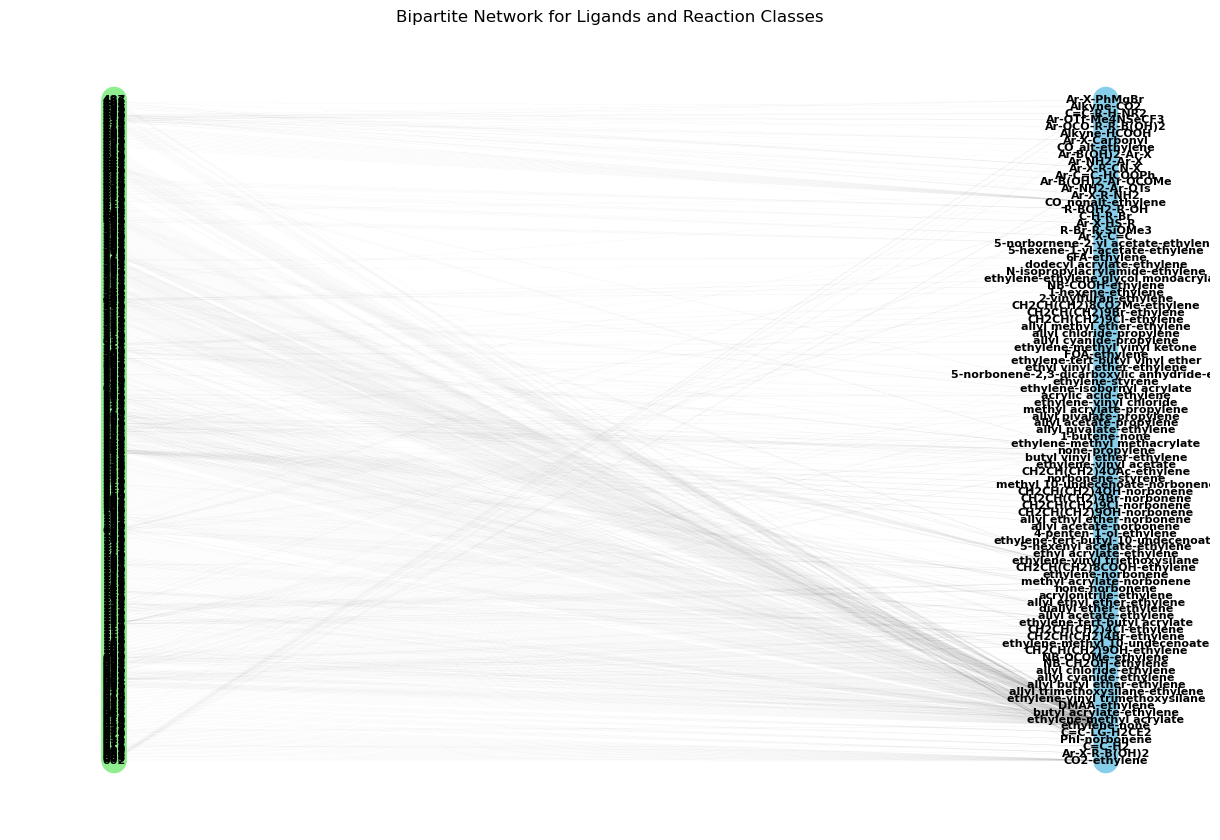

In [15]:
# Create bipartite network for visualization
# Set columns from pandas
lig_rxn_bipartite_df = lig_rxn_df[['lig_id', 'reaction_class']]

# Obtain unique list of ligand ids and reaction classes
lig_nodes = lig_rxn_bipartite_df['lig_id'].unique()
rxn_nodes = lig_rxn_bipartite_df['reaction_class'].unique()

# Create a bipartite graph
exp_bipartite = nx.Graph()

# Add nodes from the first set (ligand nodes)
exp_bipartite.add_nodes_from(lig_nodes, bipartite=0)

# Add nodes from the second set (reaction class nodes)
exp_bipartite.add_nodes_from(rxn_nodes, bipartite=1)

# Add edges based on the DataFrame
edges = list(lig_rxn_bipartite_df.itertuples(index=False, name=None))
exp_bipartite.add_edges_from(edges)

# Determine the number of nodes in each partite set
num_lig_nodes, num_rxn_nodes = len(lig_nodes), len(rxn_nodes)

print('Length of ligand nodes:', num_lig_nodes)
print('Length of reaction class nodes:', num_rxn_nodes)

# Get total possible set of edges
possible_edges = list(itertools.product(lig_nodes, rxn_nodes))

# Print the total number of possible edges
print(f"Total number of possible edges: {len(possible_edges)}")

# Determine the number of existing edges and missing edges
num_existing_edges = exp_bipartite.number_of_edges()
num_possible_edges = num_lig_nodes * num_rxn_nodes
num_missing_edges = num_possible_edges - num_existing_edges

print('Number of existing edges:', num_existing_edges)
print('Number of possible edges:', num_possible_edges)
print('Number of missing edges:', num_missing_edges)

# Plot the bipartite graph
font_size = 8
edge_width = 0.01
pos = nx.bipartite_layout(exp_bipartite, nodes=lig_nodes)

# Draw nodes and edges
plt.figure(figsize=(12, 8))

# Define colors for the nodes
node_colors = ['lightgreen' if node in lig_nodes else 'skyblue' for node in exp_bipartite.nodes()]

nx.draw(
    exp_bipartite, pos, with_labels=True, font_weight='bold', 
    node_color=node_colors, font_size=font_size, width=edge_width
)

plt.title("Bipartite Network for Ligands and Reaction Classes")
plt.savefig('Bipartite_network_original_dataset.png')

plt.show()


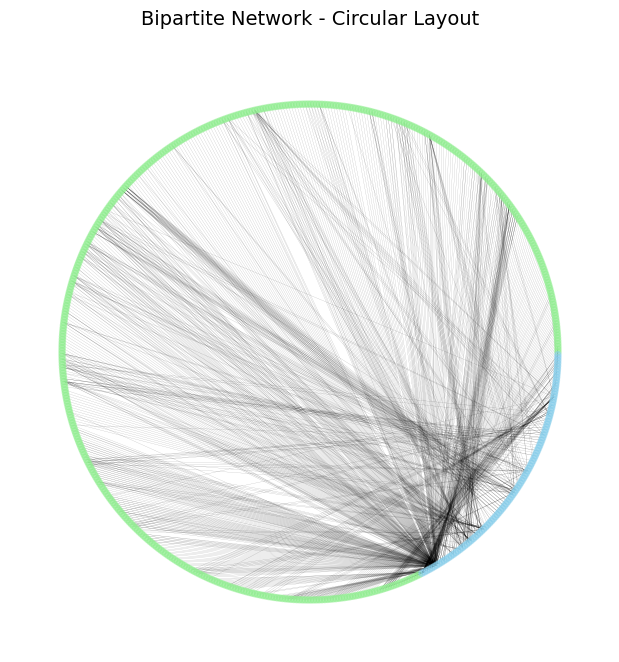

In [16]:

# Create figure
plt.figure(figsize=(6,6))

# Draw bipartite network in circular form
nx.draw(
    exp_bipartite,
    pos=nx.circular_layout(exp_bipartite),
    alpha=0.5,
    width=0.1,
    node_color=node_colors,
    node_size=20
)

# Add title
plt.title("Bipartite Network - Circular Layout", fontsize=14, pad=20)

# Save figure as PNG with high resolution
plt.savefig("bipartite_network_circular.png", format="png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

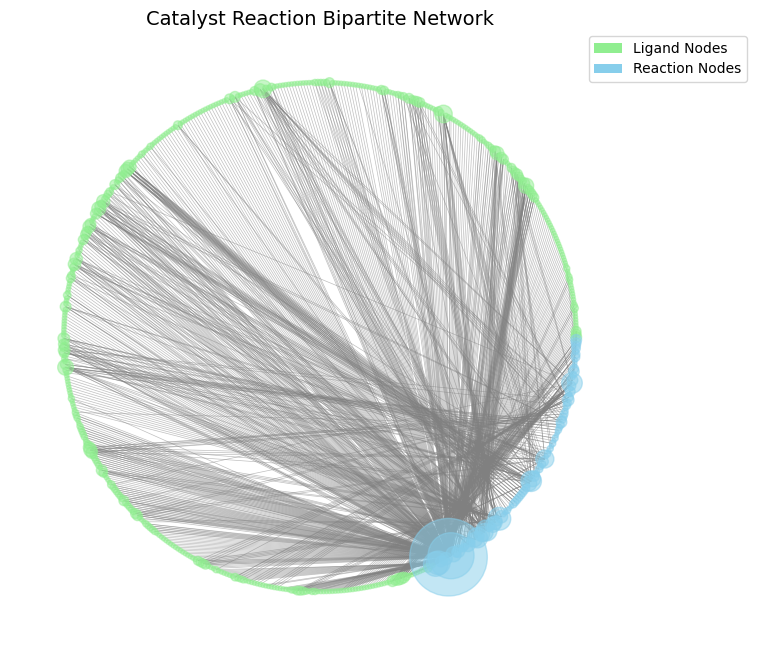

In [29]:
from matplotlib.patches import Patch

# Create custom legends
legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='none', label='Ligand Nodes'),
    Patch(facecolor='skyblue', edgecolor='none', label='Reaction Nodes')
]
plt.figure(figsize=(8,8))
# Add title
plt.title("Catalyst Reaction Bipartite Network", fontsize=14, pad=0)
# Add the legend to the plot
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))

# Get node degrees and scale node sizes
degrees = dict(exp_bipartite.degree())
node_sizes = [v * 10 for v in degrees.values()]

# Draw network with customized visual aspects
nx.draw(
    exp_bipartite, pos=nx.circular_layout(exp_bipartite), alpha=0.5, 
    width=0.5, node_color=node_colors, 
    node_size=node_sizes, edge_color='gray'
)

# # Add labels for better clarity (optional)
# nx.draw_networkx_labels(exp_bipartite, pos, font_size=8)

# Save the figure with high resolution
plt.savefig("bipartite_network_high_res.png", format="png", dpi=1600, bbox_inches='tight')
plt.savefig("bipartite_network_high_res.svg", format="svg", dpi=600)


Fold 1:
  Training set size: 928
  Test set size: 24
  Test set: [('057', 'C=C-LG-H2CE2'), ('081', 'butyl acrylate-ethylene'), ('086', 'ethylene-none'), ('107', 'ethylene-methyl acrylate'), ('122', 'ethylene-tert-butyl acrylate'), ('124', 'allyl ethyl ether-ethylene'), ('038', 'none-propylene'), ('196', 'ethylene-norbonene'), ('240', 'norbonene-styrene'), ('241', 'norbonene-styrene'), ('251', 'CO_nonalt-ethylene'), ('255', 'ethylene-vinyl acetate'), ('258', 'none-propylene'), ('258', 'ethylene-vinyl acetate'), ('267', 'ethylene-vinyl chloride'), ('272', 'butyl vinyl ether-ethylene'), ('312', 'none-propylene'), ('408', 'ethylene-none'), ('362', 'ethylene-none'), ('379', 'ethylene-methyl acrylate'), ('410', 'Ar-X-R-NH2'), ('417', 'Ar-X-R-B(OH)2'), ('441', 'ethylene-methyl acrylate'), ('479', 'Ar-OTf-Me4NSeCF3')]
Fold 2:
  Training set size: 928
  Test set size: 24
  Test set: [('013', 'CO2-ethylene'), ('015', 'CO2-ethylene'), ('032', 'ethylene-none'), ('077', 'ethylene-none'), ('084', 'e

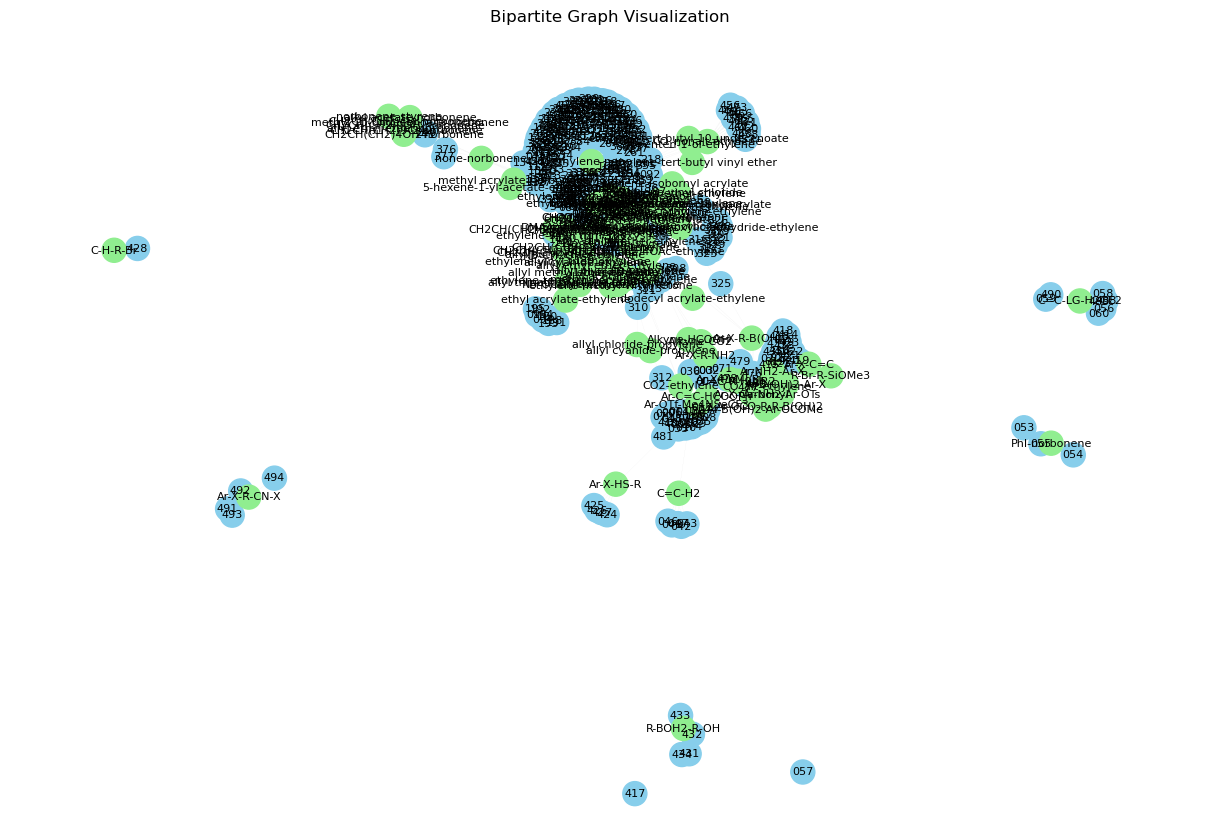

In [18]:
## Apply crossfold to create 40 training graphs

# Define 40-fold cross-validation
n_fold = 40
kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)

edge_list = list(exp_bipartite.edges())

# Split the edges into 5 folds
folds = list(kf.split(edge_list))

# Create 5-fold cross-validation sets
cv_sets = []
for train_index, test_index in folds:
    train_edges = [edge_list[i] for i in train_index]
    test_edges = [edge_list[i] for i in test_index]
    cv_sets.append((train_edges, test_edges))

# Create a list to store the new graphs
bipartite_train_list = []
test_set_list = []

# Create a dictionary to store the test-edges for each graph
dict_test_edges = {}

# Verify the cross-validation sets
for i, (train_edges, test_edges) in enumerate(cv_sets):
    print(f"Fold {i+1}:")
    print(f"  Training set size: {len(train_edges)}")
    print(f"  Test set size: {len(test_edges)}")
    print(f"  Test set: {test_edges}")
    dict_test_edges[f'test_edge_{i}'] = test_edges
    test_set_list.append(test_edges)

# Create new graphs for cross-validation by removing test edges for each fold
for i, (train_edges, test_edges) in enumerate(cv_sets):
    bipartite_train = exp_bipartite.copy()
    bipartite_train.remove_edges_from(test_edges)
    bipartite_train_list.append(bipartite_train)

    # Print the sizes of the training and test sets
    print(f"Fold {i+1}:")
    print(f"  Training set size: {len(train_edges)}")
    print(f"  Test set size: {len(test_edges)}")

# Verify the new graphs
for i, bipartite_train in enumerate(bipartite_train_list):
    print(f"bipartite_train_{i+1} number of edges: {len(bipartite_train.edges())}")

# Visualize one of the training set graphs
visualize_bipartite_graph(bipartite_train_list[0], lig_nodes, rxn_nodes)

# check_test_set(203, 'ethylene-none', dict_test_edges['test_edge_0'])

# Dictionary to store DataFrames for each graph in each cross-validation fold
df_dict_lig_rxn = {}
df_dict_cluster_lig_rxn = {}
df_dict_merged_lig_rxn = {}


In [19]:
# Determine number of existing edges, missing edges
num_existing_edges = exp_bipartite.number_of_edges()
num_possible_edges = num_lig_nodes * num_rxn_nodes
# Number of missing edges
num_missing_edges = num_possible_edges - num_existing_edges

In [20]:
num_existing_edges

952

In [21]:
len(bipartite_train_list)

40

In [22]:
# Identify which cluster dictionary is used to create ligand clusters
clusters = updated_cluster_dict_nbo_descriptor      # USE NBO/VBUR/ALL CLUSTER
cluster_type = 'NBO'
# Iterate each graph within training set

# two list: one for bipartite graph_train, one for test_set list
for idx, (G, test_edges) in enumerate(zip(bipartite_train_list, test_set_list)):
    # Get the pairs that have edges in training set graph
    edges_set = set(G.edges())

    print("Number of edges in this graph for training set: ", len(edges_set))
    # print("Number of all possible edges in this graph for training set: ", len(set(possible_edges)))
    # Find pairs with no edges between them
    training_no_edge_pairs = set(possible_edges) - edges_set
    training_no_edge_pairs = list(training_no_edge_pairs)

    # Ensure that the missing edges in each training set is equal to the sum of both the number of missing edges in the original graph and the additional ones from the test set
    assert len(training_no_edge_pairs) == num_missing_edges + len(test_edges)
    print('Number of missing edges for prediction: ', len(training_no_edge_pairs))
    
    data = []
    # Calculate link prediction measures (CN, JC, PA) for each pair of nodes without edges
    for lig_node, rxn_node in training_no_edge_pairs:
        # print('lig_node: ', lig_node, ' rxn_node: ', rxn_node)
        num_common_neighbor, jaccard_coefficient = common_neighbor_jaccard_coef(G, lig_node, rxn_node)
        preferential_lig_rxn = preferential_attachment(G, lig_node, rxn_node)
        data.append({
            'lig_node': lig_node,
            'rxn_node': rxn_node,
            'common_neighbor': num_common_neighbor,
            'jaccard_coefficient': jaccard_coefficient,
            'preferential_attachment' : preferential_lig_rxn
        })
    
    # Create the DataFrame of link prediction algorithm containing each lig-rxn pair that has missing edges, store into dictionary of dataframes
    df_neighbor = pd.DataFrame(data)
    df_dict_lig_rxn[f'graph_{idx}'] = df_neighbor
    print('Number of rows in node dataframe: ', df_dict_lig_rxn[f'graph_{idx}'].shape[0])

    # Create a new graph connecting rxn_nodes to clusters to form ligand cluster - reaction class links
    H = nx.Graph()
    H_zero = nx.Graph() #Add a H_zero graph to store data for links where weight = 0 
    # Add rxn nodes to the new graph
    H.add_nodes_from(rxn_nodes, bipartite=1)
    H_zero.add_nodes_from(rxn_nodes, bipartite=1)
    # Add cluster nodes to the new graph
    H.add_nodes_from(clusters.keys(), bipartite=0)
    H_zero.add_nodes_from(clusters.keys(), bipartite=0)

    print('Number of clusters: ', len(clusters))
    # Calculate the weights for links between clusters and rxn_nodes
    # Initialize a dictionary to store weights for cluster-rxn_node links
    cluster_rxn_weights = {cluster: {rxn: 0 for rxn in rxn_nodes} for cluster in clusters}
    
    # Create list for links with zero weight
    cluster_rxn_zero_weights = {cluster: {rxn: 0 for rxn in rxn_nodes} for cluster in clusters}    
    
    # Iterate over the original edges and update the weights for the new graph
    for lig, rxn in G.edges():
        for cluster, lig_list in clusters.items():  #extract cluster name and ligand node list within cluster
            if lig in lig_list:      
                cluster_rxn_weights[cluster][rxn] += 1
    # Add weighted edges to the new graph
    edge_added_count = 0
    for cluster, rxn_weights in cluster_rxn_weights.items():
        for rxn, w in rxn_weights.items():
            if w > 0:  # Only add edges with non-zero weight
                H.add_edge(cluster, rxn, weight=w)    #Missing some rxn, cluster combinations since there is no link.
                edge_added_count = edge_added_count + 1
            elif w == 0:
                H_zero.add_edge(cluster, rxn, weight=w)
                edge_added_count = edge_added_count + 1

    print('Edge added Count: ', edge_added_count)
    # Print the new graph edges with weights
    print("Edges in the new graph with weights:")
    
    for (u, v, wt) in H.edges(data='weight'):
        print(f"({u}, {v}, {wt})")
        
    cluster_edge_weights_list = list(H.edges(data='weight'))  # list of weights for cluster-rxn edges
    cluster_edge_zero_weights_list = list(H_zero.edges(data='weight')) # list of missing links for cluster-rxn combinations

    #Make sure number of cluster x number of rxn nodes equal to the number of all possible edges between cluster and rxn nodes
    assert len(clusters) * num_rxn_nodes == len(cluster_edge_weights_list) + len(cluster_edge_zero_weights_list)
    
    print(len(cluster_edge_weights_list)) #180 of cluster-rxn connection with weight > 0
    print(len(cluster_edge_zero_weights_list)) #210 of cluster-rxn connection with weight = 0
    
    # Create a list to store the data
    data_cluster = []

    count = 0
    # Iterate through the clusters and their connections to rxn_nodes, calculate link prediction measures 
    for rxn, cluster, weight in cluster_edge_weights_list:
        for lig in clusters[cluster]:
            count = count + 1
            degree_lig_cluster = H.degree(cluster)
            degree_rxn = H.degree(rxn)
            data_cluster.append((lig, 
                                 rxn, 
                                 weight, 
                                 len(cluster),
                                 weight / len(cluster),  #Jaccard coefficient
                                 degree_lig_cluster,
                                 degree_rxn,
                                 degree_lig_cluster * degree_rxn))   #Preferential attachment
    print("Count: ", count)
    # Add the rxn_node cluster pair with no weights in to the dataframe as well, so we can get all 105 combinations of lig and rxn
    for rxn, cluster, weight in cluster_edge_zero_weights_list:
        for lig in clusters[cluster]:
            count = count + 1
            degree_lig_cluster = H.degree(cluster)
            degree_rxn = H.degree(rxn)
            data_cluster.append((lig, 
                                 rxn, 
                                 weight, 
                                 len(cluster),
                                 weight / len(cluster),
                                 degree_lig_cluster,
                                 degree_rxn,
                                 degree_lig_cluster * degree_rxn))
    print("Count2: ", count)
    # If rxn, cluster has no link, then we still need to record the lig and rxn involved, where weight = 0, number of lig in cluster is based on cluster
    # degree of cluster is equal to cluster, # jaccard coefficient is 0, degree_rxn is based on rxn, preferential_attachment is calculated properly
    
    # Create the dataframe for cluster-rxn 
    cluster_df = pd.DataFrame(data_cluster, columns=['lig_node', 
                                                     'rxn_node', 
                                                     'common_neighbor_cluster',
                                                     'number of lig in cluster',
                                                     'jaccard_coefficient_cluster',
                                                     'degree_lig_cluster',
                                                     'degree_rxn',
                                                     'preferential_attachment_cluster'])
    
    print('Number of rows in cluster dataframe: ', cluster_df.shape[0])  #should have 105?

    # Make sure that the number of rows for the cluster dataframe is equal to the total possible combinations of all node connections
    assert cluster_df.shape[0] == len(set(possible_edges)), f"Assertion failed: cluster_df.shape[0] = {cluster_df.shape[0]}, len(set(possible_edges)) = {len(set(possible_edges))}"

    # Create a DataFrame from training_no_edge_pairs
    training_no_edge_pairs_df = pd.DataFrame(training_no_edge_pairs, columns=['lig_node', 'rxn_node'])
    print('Number of rows in no edge pair dataframe: ', training_no_edge_pairs_df.shape[0])
    
    # Merge the cluster_df with training_no_edge_pairs_df on lig_node and rxn_node
    filtered_cluster_df = pd.merge(cluster_df, training_no_edge_pairs_df, on=['lig_node', 'rxn_node'])
    
    # Store dataframe into a dictionary of dataframes
    df_dict_cluster_lig_rxn[f'graph_{idx}'] = filtered_cluster_df

    df_dict_merged_lig_rxn[f'graph_{idx}'] = pd.merge(df_dict_lig_rxn[f'graph_{idx}'], df_dict_cluster_lig_rxn[f'graph_{idx}'], on=['lig_node', 'rxn_node'], how='inner')
    # print('Number of rows in merged dataframe: ', df_dict_merged_lig_rxn[f'graph_{idx}'].shape[0])

    # Make sure that the number of rows after merging is equal to the number of missing pairs from the training graph 
    assert df_dict_merged_lig_rxn[f'graph_{idx}'].shape[0] == len(training_no_edge_pairs)

# Check graph_0 within both dictionary
# print('Dataframe_neighbors: ',df_dict_lig_rxn['graph_0'])
# print('Dataframe_clusters: ',df_dict_cluster_lig_rxn['graph_0'])  
# print('Merged dataframe: ',df_dict_merged_lig_rxn['graph_0']) 
column_list = df_dict_merged_lig_rxn['graph_0'].columns.tolist() 
print(column_list)

Number of edges in this graph for training set:  928
Number of missing edges for prediction:  43304
Number of rows in node dataframe:  43304
Number of clusters:  4
Edge added Count:  388
Edges in the new graph with weights:
(CO2-ethylene, c1, 9)
(CO2-ethylene, c2, 1)
(CO2-ethylene, c3, 19)
(CO2-ethylene, c4, 2)
(Ar-X-R-B(OH)2, c1, 17)
(Ar-X-R-B(OH)2, c3, 10)
(Ar-X-R-B(OH)2, c4, 1)
(C=C-H2, c3, 6)
(PhI-norbonene, c3, 3)
(C=C-LG-H2CE2, c1, 1)
(C=C-LG-H2CE2, c3, 3)
(C=C-LG-H2CE2, c4, 3)
(ethylene-none, c1, 132)
(ethylene-none, c2, 97)
(ethylene-none, c3, 12)
(ethylene-none, c4, 68)
(ethylene-methyl acrylate, c1, 43)
(ethylene-methyl acrylate, c2, 39)
(ethylene-methyl acrylate, c3, 1)
(ethylene-methyl acrylate, c4, 24)
(butyl acrylate-ethylene, c1, 3)
(butyl acrylate-ethylene, c2, 4)
(butyl acrylate-ethylene, c4, 4)
(DMAA-ethylene, c4, 4)
(ethylene-vinyl trimethoxysilane, c2, 7)
(ethylene-vinyl trimethoxysilane, c3, 1)
(allyl trimethoxysilane-ethylene, c3, 1)
(allyl butyl ether-ethylene, c

In [23]:
# Evaluate Precision & AUPR for each cross validation by using the test set established earlier:
# Iterate through each dataframe. For each dataframe, obtain rows with test set node pairs only (which should all be 1) normalize prediction scores, 
# Generate Precision & AUPR for that dataframe for each link prediction algorithm
# Then obtain average AUC and AUPR for all dataframe to reach link prediction algorithm 
# References for understanding link prediction evaluation metrics:
# Simone Daminelli et al 2015 New J. Phys. 17 113037 Main journal used for adopting precision & aupr over auc
# Yang, Y., Lichtenwalter, R.N. & Chawla, N.V. Evaluating link prediction methods. Knowl Inf Syst 45, 751–782 (2015). States that ROC is deceptive.
    
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score #Not accurate for checking area under AUC. https://datascience.stackexchange.com/questions/52130/about-sklearn-metrics-average-precision-score-documentation
from sklearn.metrics import precision_recall_curve, auc

score_column = ['common_neighbor', 
                'jaccard_coefficient', 
                'preferential_attachment', 
                'common_neighbor_cluster', 
                'jaccard_coefficient_cluster', 
                'preferential_attachment_cluster']

# Initialize DataFrames to store AUC and AUPR scores
auc_df = pd.DataFrame(index=score_column)
aupr_df = pd.DataFrame(index=score_column)
all_results = []

for idx in range(n_fold):
    df_merge = df_dict_merged_lig_rxn[f'graph_{idx}'] # Get all missing edges from the training set graph
    num_missing_edges_test_set = df_dict_merged_lig_rxn[f'graph_{idx}'].shape[0] #Number of missing edges and test set from the training set graph
    print('Number of missing edges and test set from the training set graph: ', num_missing_edges_test_set)
    # Normalize each column
    for column in score_column:
        min_value = df_merge[column].min()
        max_value = df_merge[column].max()
        df_merge[column] = (df_merge[column] - min_value) / (max_value - min_value)

    #print('df_merge_normalized: ', df_merge)
    test_edges_set = set(dict_test_edges[f'test_edge_{idx}']) # Used to identify the test_edges

    l = len(test_edges_set)    # Set l as number of test edges
    
    # print('List of test edges:', test_edges_set)
    print('Length of test edges list: ', l)
    # Create a new column in df_merge called 'actual outcome'
    # For lig_node and rxn_nodes that are within the list_test_edges, put 1 in the actual outcome
    # For the rest of the nodes, put 0
    df_merge['actual outcome'] = df_merge.apply(lambda row: 1 if (row['lig_node'], row['rxn_node']) in test_edges_set else 0, axis=1)
    print(df_merge)
    # Save df_merge to a CSV file named 'link_compare_idx.csv'
    df_merge.to_csv(f'link_compare_{idx}.csv', index=False)

    # Iterate through each prediction algorithm and calculate the metrics
    results = []
    for score_type in score_column:
        precision_at_L, aupr = calculate_metric(df_merge, score_type, l, top_L=None)
        results.append({'Score_type': score_type, 'precision_at_L': precision_at_L, 'aupr': aupr})
        
    # Convert the results to a DataFrame
    results_df = pd.DataFrame(results)

    # Append to all results
    all_results.append(results_df)
    
    # Display the results
    print(results_df)


# Concatenate all results DataFrames into a single DataFrame
concatenated_results = pd.concat(all_results)

# Group by algorithm and calculate the mean of precision_at_L and aupr
average_results = concatenated_results.groupby('Score_type').mean().reset_index()
    # Iterate through each prediction algorithm, by creating a dataframe where we have the lig_node, rxn_node, prediction algorithm, and actual outcome
    # sort rows based on the normalized score under the prediction algorithm
    # Obtain precision value by analyzing how many 1s are there in the top L rows out of L rows
    # Obtain AUPR with both column
# Display the average results
print('Average results: ', average_results)


Number of missing edges and test set from the training set graph:  43304
Length of test edges list:  24
      lig_node                     rxn_node  common_neighbor  \
0          467                Ar-NH2-Ar-OTs         0.000000   
1          166  allyl ethyl ether-norbonene         0.000000   
2          386               none-norbonene         0.054545   
3          016      CH2CH(CH2)9OH-norbonene         0.000000   
4          318               Ar-B(OH)2-Ar-X         0.000000   
...        ...                          ...              ...   
43299      021             NB-COOH-ethylene         0.000000   
43300      203      CH2CH(CH2)9Cl-norbonene         0.000000   
43301      153                Ar-X-Carbonyl         0.000000   
43302      077                R-Br-R-SiOMe3         0.000000   
43303      409       allyl cyanide-ethylene         0.036364   

       jaccard_coefficient  preferential_attachment  common_neighbor_cluster  \
0                 0.000000                 0.00

In [24]:
average_results

,Score_type,precision_at_L,aupr
0,common_neighbor,0.098868,0.057472
1,common_neighbor_cluster,0.051449,0.094488
2,jaccard_coefficient,0.001042,0.084742
3,jaccard_coefficient_cluster,0.051449,0.094488
4,preferential_attachment,0.067346,0.019026
5,preferential_attachment_cluster,0.008333,0.105421


In [25]:
# Apply LOOCV 
# Method: Take some links out, See if we can obtain that missing link combinations in the top 5%, 10%, 15% 20% and 25% positions. AKA keep 
# length of test set consistent, but change the top_L threshold
# Identify the average percentage of recovery.
# Current method: Set L as number of length of test set

# Evaluate Precision & AUPR for each cross validation by using the test set established earlier:
# Iterate through each dataframe. For each dataframe, obtain rows with test set node pairs only (which should all be 1) normalize prediction scores, 
# Generate Precision & AUPR for that dataframe for each link prediction algorithm
# Then obtain average AUC and AUPR for all dataframe to reach link prediction algorithm 
# References for understanding link prediction evaluation metrics:
# Simone Daminelli et al 2015 New J. Phys. 17 113037 Main journal used for adopting precision & aupr over auc
# Yang, Y., Lichtenwalter, R.N. & Chawla, N.V. Evaluating link prediction methods. Knowl Inf Syst 45, 751–782 (2015). States that ROC is deceptive.
    
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score #Not accurate for checking area under AUC. https://datascience.stackexchange.com/questions/52130/about-sklearn-metrics-average-precision-score-documentation
from sklearn.metrics import precision_recall_curve, auc

score_column = ['common_neighbor', 
                'jaccard_coefficient', 
                'preferential_attachment', 
                'common_neighbor_cluster', 
                'jaccard_coefficient_cluster', 
                'preferential_attachment_cluster']

# Initialize DataFrames to store AUC and AUPR scores
auc_df = pd.DataFrame(index=score_column)
aupr_df = pd.DataFrame(index=score_column)
all_results = []

for idx in range(n_fold):
    df_merge = df_dict_merged_lig_rxn[f'graph_{idx}'] # Get all missing edges from the training set graph
    num_missing_edges_test_set = df_dict_merged_lig_rxn[f'graph_{idx}'].shape[0] #Number of missing edges and test set from the training set graph
    print('Number of missing edges and test set from the training set graph: ', num_missing_edges_test_set)
    
    # Normalize each column
    for column in score_column:
        min_value = df_merge[column].min()
        max_value = df_merge[column].max()
        df_merge[column] = (df_merge[column] - min_value) / (max_value - min_value)

    #print('df_merge_normalized: ', df_merge)
    test_edges_set = set(dict_test_edges[f'test_edge_{idx}']) # Used to identify the test_edges

    l = len(test_edges_set)    # Set l as number of test edges
    
    # print('List of test edges:', test_edges_set)
    print('Length of test edges list: ', l)
    # Create a new column in df_merge called 'actual outcome'
    # For lig_node and rxn_nodes that are within the list_test_edges, put 1 in the actual outcome
    # For the rest of the nodes, put 0
    df_merge['actual outcome'] = df_merge.apply(lambda row: 1 if (row['lig_node'], row['rxn_node']) in test_edges_set else 0, axis=1)
    # Save df_merge to a CSV file named 'link_compare_idx.csv'
    df_merge.to_csv(f'link_compare_{idx}.csv', index=False)

    # Iterate through each prediction algorithm and calculate the metrics
    results = []
    top_percentage_of_missing_edges = [0.01,0.025,0.05,0.1,0.2,0.3,0.4,0.5]
    for percent in top_percentage_of_missing_edges:
        top_L = round(percent*num_missing_edges_test_set)
        print('Top_L:', top_L)
        for score_type in score_column:
            precision_at_L, aupr = calculate_metric(df_merge, score_type, l, top_L)     #l = percentage * number of missing edges
            results.append({'Top_L:': top_L, 'Score_type': score_type, 'precision_at_L': precision_at_L, 'aupr': aupr})
        
    # Convert the results to a DataFrame
    results_df = pd.DataFrame(results)

    # Append to all results
    all_results.append(results_df)
    
    # Display the results
    # print(results_df)


# Concatenate all results DataFrames into a single DataFrame
concatenated_results = pd.concat(all_results)
print(concatenated_results)



# Group by both Top_L and Score_type and calculate mean precision and AUPR
avg_by_topL_and_score = concatenated_results.groupby(['Top_L:', 'Score_type'])[['precision_at_L', 'aupr']].mean().reset_index()

# Display the result
print(avg_by_topL_and_score)


# # Group by algorithm and calculate the mean of precision_at_L and aupr
# average_results = concatenated_results.groupby('Score_type').mean().reset_index()
#     # Iterate through each prediction algorithm, by creating a dataframe where we have the lig_node, rxn_node, prediction algorithm, and actual outcome
#     # sort rows based on the normalized score under the prediction algorithm
#     # Obtain precision value by analyzing how many 1s are there in the top L rows out of L rows
#     # Obtain AUPR with both column
# # Display the average results
# print('Average results: ', average_results)

unique_top_L_values = avg_by_topL_and_score['Top_L:'].unique()
print(unique_top_L_values)

Number of missing edges and test set from the training set graph:  43304
Length of test edges list:  24
Top_L: 433
Top_L: 1083
Top_L: 2165
Top_L: 4330
Top_L: 8661
Top_L: 12991
Top_L: 17322
Top_L: 21652
Number of missing edges and test set from the training set graph:  43304
Length of test edges list:  24
Top_L: 433
Top_L: 1083
Top_L: 2165
Top_L: 4330
Top_L: 8661
Top_L: 12991
Top_L: 17322
Top_L: 21652
Number of missing edges and test set from the training set graph:  43304
Length of test edges list:  24
Top_L: 433
Top_L: 1083
Top_L: 2165
Top_L: 4330
Top_L: 8661
Top_L: 12991
Top_L: 17322
Top_L: 21652
Number of missing edges and test set from the training set graph:  43304
Length of test edges list:  24
Top_L: 433
Top_L: 1083
Top_L: 2165
Top_L: 4330
Top_L: 8661
Top_L: 12991
Top_L: 17322
Top_L: 21652
Number of missing edges and test set from the training set graph:  43304
Length of test edges list:  24
Top_L: 433
Top_L: 1083
Top_L: 2165
Top_L: 4330
Top_L: 8661
Top_L: 12991
Top_L: 17322
Top

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
5      1.0
6      3.0
7      3.0
8      3.0
9      3.0
10     3.0
11     3.0
12     5.0
13     5.0
14     5.0
15     5.0
16     5.0
17     5.0
18    10.0
19    10.0
20    10.0
21    10.0
22    10.0
23    10.0
24    20.0
25    20.0
26    20.0
27    20.0
28    20.0
29    20.0
30    30.0
31    30.0
32    30.0
33    30.0
34    30.0
35    30.0
36    40.0
37    40.0
38    40.0
39    40.0
40    40.0
41    40.0
42    40.0
43    40.0
44    40.0
45    40.0
46    40.0
47    40.0
48    50.0
49    50.0
50    50.0
51    50.0
52    50.0
53    50.0
Name: Top_L_percent, dtype: float64


<Figure size 1200x1200 with 0 Axes>

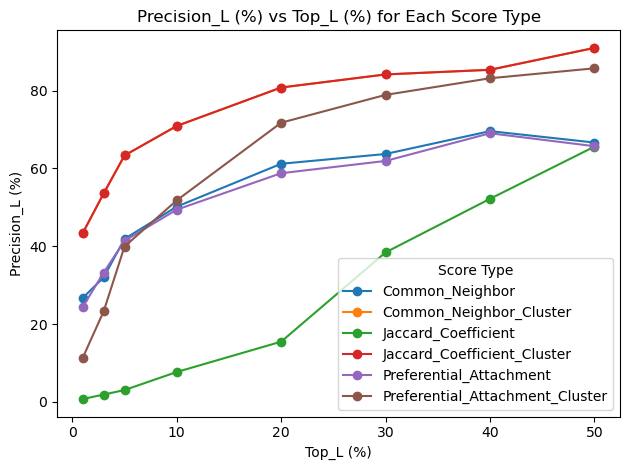

In [28]:
# PLot results with line graph

Top_L_df = pd.DataFrame(avg_by_topL_and_score)
# Create a new column with Top_L as a percentage
Top_L_df['Top_L_percent'] = round((Top_L_df['Top_L:'] / num_missing_edges_test_set) * 100)
print(Top_L_df['Top_L_percent'])
# Convert precision to percentage
Top_L_df['precision_percent'] = Top_L_df['precision_at_L'] * 100

Top_L_df= Top_L_df.drop_duplicates(subset=['Top_L_percent', 'Score_type'])

# Pivot using Top_L_percent instead of Top_L:
pivot_precision_pct = Top_L_df.pivot(index='Top_L_percent', columns='Score_type', values='precision_percent')

# Plot
plt.figure(figsize=(12, 12))
ax = pivot_precision_pct.plot(marker='o')

# Title-case legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [label.title() for label in labels], title='Score Type', loc='lower right')

plt.title('Precision_L (%) vs Top_L (%) for Each Score Type')
plt.xlabel('Top_L (%)')
plt.ylabel('Precision_L (%)')
plt.grid(False)
plt.tight_layout()
plt.savefig('precision_plot.png', dpi=1600, bbox_inches='tight')
plt.savefig("precision_plot.svg", format="svg", dpi=600)
plt.show()



In [ ]:
pivot_precision_pct = pivot_precision_pct.round(1)
pivot_precision_pct

## After assesssing which score_type is better, apply it to predict candidates
## Make function to choose a candidate, and then score different reaction classes from the ligand
## Make function to chose a reaction class, and then rank different ligand for that reaction class

### Update: Need to remove 'known' links 

In [ ]:
# Identify which cluster dictionary is used to create ligand clusters
if clusters is updated_cluster_dict_nbo_descriptor:
    print('Cluster dictionary used for creating ligand clusters: NBO')
elif clusters is updated_cluster_dict_vbur_descriptor:
    print('Cluster dictionary used for creating ligand clusters: Vbur')
elif clusters is updated_cluster_dict_all_descriptor:
    print('Cluster dictionary used for creating ligand clusters: All')
else:
    print('Unknown cluster dictionary')
# clusters = updated_cluster_dict_nbo_descriptor 

edge_set = set(exp_bipartite.edges()) 

num_no_edge_pairs = list(set(possible_edges) - edges_set)

for lig_node, rxn_node in num_no_edge_pairs:
    # print('lig_node: ', lig_node, ' rxn_node: ', rxn_node)
    num_common_neighbor, jaccard_coefficient = common_neighbor_jaccard_coef(exp_bipartite, lig_node, rxn_node)
    preferential_lig_rxn = preferential_attachment(exp_bipartite, lig_node, rxn_node)
    data.append({
        'lig_node': lig_node,
        'rxn_node': rxn_node,
        'common_neighbor': num_common_neighbor,
        'jaccard_coefficient': jaccard_coefficient,
        'preferential_attachment' : preferential_lig_rxn
    })

# Create the DataFrame of link prediction algorithm containing each lig_rxn pair that has missing edges, store into dictionary of dataframes
df_all_neighbor = pd.DataFrame(data)
df_all_neighbor = df_all_neighbor.drop_duplicates(subset=['lig_node', 'rxn_node'])


# Create a new graph connecting rxn_nodes to clusters to form ligand cluster - reaction class links
H = nx.Graph()
H_zero = nx.Graph() #Add a H_zero graph to store data for links where weight = 0 
# Add rxn nodes to the new graph
H.add_nodes_from(rxn_nodes, bipartite=1)
H_zero.add_nodes_from(rxn_nodes, bipartite=1)
# Add cluster nodes to the new graph
H.add_nodes_from(clusters.keys(), bipartite=0)
H_zero.add_nodes_from(clusters.keys(), bipartite=0)

print('Number of clusters: ', len(clusters))
# Calculate the weights for links between clusters and rxn_nodes
# Initialize a dictionary to store weights for cluster-rxn_node links
cluster_rxn_weights = {cluster: {rxn: 0 for rxn in rxn_nodes} for cluster in clusters}

# Create list for links with zero weight
cluster_rxn_zero_weights = {cluster: {rxn: 0 for rxn in rxn_nodes} for cluster in clusters}    

# Iterate over the original edges and update the weights for the new graph
for lig, rxn in exp_bipartite.edges():
    for cluster, lig_list in clusters.items():  #extract cluster name and ligand node list within cluster
        if lig in lig_list:      
            cluster_rxn_weights[cluster][rxn] += 1
# Add weighted edges to the new graph
edge_added_count = 0
for cluster, rxn_weights in cluster_rxn_weights.items():
    for rxn, w in rxn_weights.items():
        if w > 0:  # Only add edges with non-zero weight
            H.add_edge(cluster, rxn, weight=w)    #Missing some rxn, cluster combinations since there is no link.
            edge_added_count = edge_added_count + 1
        elif w == 0:
            H_zero.add_edge(cluster, rxn, weight=w)
            edge_added_count = edge_added_count + 1

print('Edge added Count: ', edge_added_count)
# Print the new graph edges with weights
print("Edges in the new graph with weights:")

for (u, v, wt) in H.edges(data='weight'):
    print(f"({u}, {v}, {wt})")
    
cluster_edge_weights_list = list(H.edges(data='weight'))  # list of weights for cluster-rxn edges
cluster_edge_zero_weights_list = list(H_zero.edges(data='weight')) # list of missing links for cluster-rxn combinations

#Make sure number of cluster x number of rxn nodes equal to the number of all possible edges between cluster and rxn nodes
assert len(clusters) * num_rxn_nodes == len(cluster_edge_weights_list) + len(cluster_edge_zero_weights_list)

print('Number of rxn nodes:', num_rxn_nodes)
print('Number of lig nodes:', num_lig_nodes)

# Create a list to store the data
data_cluster = []

count = 0
# Iterate through the clusters and their connections to rxn_nodes, calculate link prediction measures 
for rxn, cluster, weight in cluster_edge_weights_list:
    for lig in clusters[cluster]:
        count = count + 1
        degree_lig_cluster = H.degree(cluster)
        degree_rxn = H.degree(rxn)
        data_cluster.append((lig, 
                             rxn, 
                             weight, 
                             len(cluster),
                             weight/len(cluster), #Jaccard coefficient
                             degree_lig_cluster,
                             degree_rxn,
                             degree_lig_cluster * degree_rxn))   #Preferential attachment
print("Count: ", count)
# Add the rxn_node cluster pair with no weights in to the dataframe as well, so we can get all 105 combinations of lig and rxn
for rxn, cluster, weight in cluster_edge_zero_weights_list:
    for lig in clusters[cluster]:
        count = count + 1
        degree_lig_cluster = H.degree(cluster)
        degree_rxn = H.degree(rxn)
        data_cluster.append((lig, 
                             rxn, 
                             weight, 
                             len(cluster),
                             weight/len(cluster),
                             degree_lig_cluster,
                             degree_rxn,
                             degree_lig_cluster * degree_rxn))
print("Count2: ", count)
# If rxn, cluster has no link, then we still need to record the lig and rxn involved, where weight = 0, number of lig in cluster is based on cluster
# degree of cluster is equal to cluster, # jaccard coefficient is 0, degree_rxn is based on rxn preferential_attachment is calculated properly

# Create the dataframe for cluster-rxn 
cluster_df = pd.DataFrame(data_cluster, columns=['lig_node', 
                                                 'rxn_node', 
                                                 'common_neighbor_cluster',
                                                 'number of lig in cluster',
                                                 'jaccard_coefficient_cluster',
                                                 'degree_lig_cluster',
                                                 'degree_rxn',
                                                 'preferential_attachment_cluster'])

print('Number of rows in cluster dataframe: ', cluster_df.shape[0])  

# Make sure that the number of rows for the cluster dataframe is equal to the total possible combinations of all node connections
assert cluster_df.shape[0] == len(set(possible_edges)), f"Assertion failed: cluster_df.shape[0] = {cluster_df.shape[0]}, len(set(possible_edges)) = {len(set(possible_edges))}"

In [ ]:
df_all_neighbor 

In [ ]:
# Merge the two dataframes on lig_node and rxn_node to obtain all link prediction measures for missing links in the experimental bipartite network
merged_df = pd.merge(df_all_neighbor, cluster_df, on=['lig_node', 'rxn_node'])

# Display the merged dataframe
merged_df


In [ ]:
# Filter rows where the 'rxn_node' column contains the string 'CO2-ethylene'

reaction_name = 'CO_alt'

filtered_df = merged_df[merged_df['rxn_node'].str.contains(reaction_name, na=False)]

filtered_df_sorted = filtered_df.sort_values(
    by=['preferential_attachment_cluster','jaccard_coefficient_cluster',],  #Sort ranking based on score_type with good precision
    ascending=[False, False]
)

# Display the filtered DataFrame
display(filtered_df_sorted)

# Ensure both keys are the same type (e.g., int or str)
filtered_df_sorted['lig_node'] = filtered_df_sorted['lig_node'].astype(int)
df['lig_id'] = df['lig_id'].astype(int)

# Merge the two DataFrames
df_sorted_with_info = pd.merge(
    filtered_df_sorted,
    df[['lig_id', 'SMILES', 'ligand_name']],
    left_on='lig_node',
    right_on='lig_id',
    how='left'
)

# Optionally drop the duplicate 'lig_id' column after merging
df_sorted_with_info = df_sorted_with_info.drop(columns=['lig_id'])

# Remove duplicate rows (based on all columns)
df_sorted_with_info = df_sorted_with_info.drop_duplicates()

# (Optional) Reset index
df_sorted_with_info = df_sorted_with_info.reset_index(drop=True)

# Preview the result
display(df_sorted_with_info.head())


# Save the filtered DataFrame to a CSV file
df_sorted_with_info.to_csv('filtered_'+ reaction_name + '.csv', index=False)

In [ ]:
# Define the function to get top 20 rxn_nodes with renamed columns
def get_top_20_rxn_nodes(df, lig_node, measure):
    # Filter the DataFrame for the specified lig_node
    filtered_df = df[df['lig_node'] == lig_node]
    
    # Sort the DataFrame by the specified measure in descending order
    sorted_df = filtered_df.sort_values(by=measure, ascending=False)
    
    # Select the top 20 rxn_nodes and rename columns
    top_20_rxn_nodes = sorted_df.head(100)[['rxn_node', measure]]
    top_20_rxn_nodes = top_20_rxn_nodes.rename(columns={'rxn_node': 'Reaction', measure: 'Confidence'})
    
    return top_20_rxn_nodes

# Define the function to get top 20 lig_nodes with renamed columns
def get_top_20_lig_nodes(df, rxn_node, measure):
    # Filter the DataFrame for the specified rxn_node
    filtered_df = df[df['rxn_node'] == rxn_node]
    
    # Sort the DataFrame by the specified measure in descending order
    sorted_df = filtered_df.sort_values(by=measure, ascending=False)
    
    # Select the top 20 lig_nodes and rename columns
    top_20_lig_nodes = sorted_df.head(100)[['lig_node', measure]]
    top_20_lig_nodes = top_20_lig_nodes.rename(columns={'lig_node': 'Ligand', measure: 'Confidence'})
    
    return top_20_lig_nodes

# Example usage for lig_node
lig_node = '038'
measure = 'common_neighbor_cluster'
top_20_rxn_nodes = get_top_20_rxn_nodes(merged_df, lig_node, measure)
print("Top 20 Reactions for Ligand {} based on Confidence:".format(lig_node))
display(top_20_rxn_nodes)

# Example usage for rxn_node
rxn_node = 'CO_alt-ethylene'
measure = 'common_neighbor_cluster'
top_20_lig_nodes = get_top_20_lig_nodes(merged_df, rxn_node, measure)
print("Top 20 Ligands for Reaction {} based on Confidence:".format(rxn_node))
display(top_20_lig_nodes)


In [ ]:
# Why is CO-nonalternating ethylene so weird??
# Check cluster 
# Change cluster?

In [ ]:
df

In [ ]:
## Check if it shows result that already have link with reaction:
## Generate SMILES for pandas

# Ensure 'Ligand' in top_20_lig_nodes and 'lig_id' in df are of the same type
# Convert both to strings just to be safe (optional, depending on your data)
top_20_lig_nodes['Ligand'] = top_20_lig_nodes['Ligand'].astype(int)
df['lig_id'] = df['lig_id'].astype(int)

top_20_lig_nodes_smiles_df = pd.merge(top_20_lig_nodes, df[['lig_id', 'SMILES', 'ligand_name']], left_on='Ligand', right_on='lig_id', how='left')
# Drop the 'lig_id' column after merging (optional)
top_20_lig_nodes_smiles_df = top_20_lig_nodes_smiles_df.drop(columns=['lig_id'])
top_20_lig_nodes_smiles_df = top_20_lig_nodes_smiles_df.drop_duplicates()

# Display the result
top_20_lig_nodes_smiles_df.to_csv('top_20_lig_nodes_smiles.csv', index=False)
display(top_20_lig_nodes_smiles_df)


In [ ]:
# 55, 315, 390, 386, 263, 318, 291
# Stuff to fix: why is it recommending nodes that already have link with CO2-ethylene? SOmething is going wrong. 

In [ ]:
# Changes: Add the ability to use SMILES from ligand database and draw it 

In [ ]:
exp_bipartite

In [ ]:
import networkx as nx

def get_neighbors_of_degree(graph, node, max_degree):
    """
    Get the neighbors of a given node up to a specified degree and the count of nodes at each degree.
    
    Parameters:
    - graph: networkx.Graph
    - node: the node to examine
    - max_degree: the maximum degree up to which neighbors should be returned
    
    Returns:
    - neighbors_by_degree: a dictionary where keys are degrees and values are sets of nodes
    - counts_by_degree: a dictionary where keys are degrees and values are the counts of nodes
    """
    if node not in graph:
        raise ValueError("Node not found in the graph")
    
    neighbors_by_degree = {0: {node}}
    counts_by_degree = {0: 1}
    current_level = {node}
    
    for degree in range(1, max_degree + 1):
        next_level = set()
        for n in current_level:
            next_level.update(graph.neighbors(n))
        next_level -= neighbors_by_degree[degree - 1]  # Remove already seen nodes
        neighbors_by_degree[degree] = next_level
        counts_by_degree[degree] = len(next_level)
        current_level = next_level
    
    return neighbors_by_degree, counts_by_degree

# Example usage:
B = nx.Graph()
# Add edges (assume it's a bipartite graph)
B.add_edges_from([('A', 1), ('A', 2), ('B', 2), ('C', 3), ('C', 4), ('D', 4)])

node = 'A'
max_degree = 2
neighbors_by_degree, counts_by_degree = get_neighbors_of_degree(B, node, max_degree)
print(f"Neighbors of node '{node}' up to degree {max_degree}: {neighbors_by_degree}")
print(f"Counts of nodes by degree: {counts_by_degree}")


In [ ]:
# Use function for exp_bipartite graph
node = '317'
max_degree = 3
neighbors_by_degree, counts_by_degree = get_neighbors_of_degree(exp_bipartite, node, max_degree)
print(f"Neighbors of node '{node}' up to degree {max_degree}: {neighbors_by_degree}")
print(f"Counts of nodes by degree: {counts_by_degree}")

In [ ]:
def draw_graph_with_highlight(graph, neighbors_by_degree, degree):
    pos = nx.circular_layout(graph)
    plt.figure(figsize=(8, 8))
    
    # Draw the base graph
    nx.draw(graph, pos, with_labels=False, node_color='lightgrey', node_size=50, edge_color='grey', width=0.5)
    
    # Highlight the nodes up to the specified degree
    for d in range(degree + 1):
        nodes = neighbors_by_degree[d]
        nx.draw_networkx_nodes(graph, pos, nodelist=nodes, node_color=f"C{d}", node_size=70, label=f"Degree {d}")
    
    plt.legend()
    plt.title(f"Nodes up to degree {degree}")
    plt.show()


In [ ]:
for d in range(max_degree + 1):
    draw_graph_with_highlight(exp_bipartite, neighbors_by_degree, d)

In [ ]:
## Prediction for Ni-catalyzed alternating and non-alternating polyketone synthesis
## Evaluate all reactions in terms of Ni/Pd overlap - create a table to examine which reaction shows literature precendent of overlappinng metals (use ranking to determine confidence)
## the more, the better the recommendation if we use a ligand from the opposite metal 
## Evaluate all ligands in terms of Ni/Pd overlap in literature - create a table to examine which ligand shows literature examples of overlapping metals